In [5]:
import pymaster as nmt
import matplotlib.pyplot as plt
import healpy as hp
from tqdm import tqdm


## Load the DESI LRG catalog:

In [6]:
# Example script that applies the same quality & footprint cuts on the LRG catalog as in White et al. 2022
import numpy as np
from astropy.table import Table
import fitsio
import healpy as hp

min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

ldir = '/mnt/ceph/users/spandey/xdesi/lrg_xcorr_2023/v1'

cat = Table(fitsio.read(f'{ldir}/catalogs/dr9_lrg_pzbins.fits'))
weights = Table(fitsio.read(f'{ldir}/catalogs/more/dr9_lrg_pzbins-weights.fits'))['weight']
# combine the two tables into a single table:
cat['weight'] = weights
print(len(cat))

# Remove "islands" in the NGC
mask = ~((cat['DEC']<-10.5) & (cat['RA']>120) & (cat['RA']<260))
print('Remove islands', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# NOBS cut
mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# EBV cut
mask = cat['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Stellar density cut
stardens = fitsio.read(f'{ldir}/misc/pixweight-dr7.1-0.22.0_stardens_64_ring.fits')  # Stellar density map
stardens_nside = 64
mask = stardens['STARDENS']>=max_stardens
bad_hp_idx = stardens['HPXPIXEL'][mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['RA'], cat['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

print(len(cat), cat.keys())




12392209
Remove islands 12315675 76534 0.9938240228194989
NOBS 11733330 582345 0.9527151374163414
LRG mask 10355201 1378129 0.11745420950403679
EBV 10225401 129800 0.012534763931670665
STARDENS 9996023 229378 0.022432176498506023
9996023 ['TARGETID', 'RA', 'DEC', 'EBV', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'MASKBITS', 'PHOTSYS', 'Z_PHOT_MEDIAN', 'lrg_mask', 'pz_bin', 'weight']


## Get n(z) for the four bins:

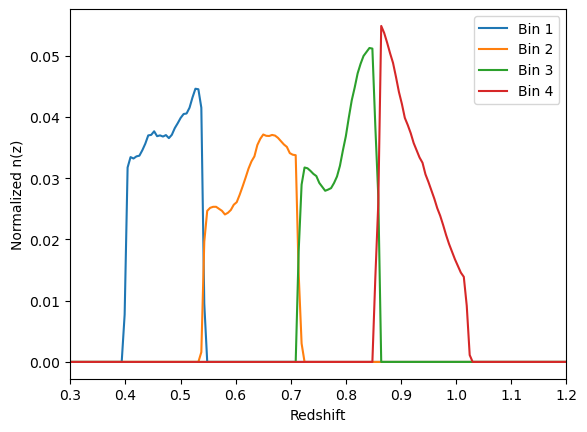

In [7]:
nbins_gals = 4
z_array_nz = np.linspace(0, 1.6, 300)
nz_bins = []
for i in range(nbins_gals):
    zmin = i*0.4
    zmax = (i+1)*0.4
    # mask = (cat['Z']>=zmin) & (cat['Z']<zmax)
    mask = cat['pz_bin']==i+1
    nz, _ = np.histogram(cat['Z_PHOT_MEDIAN'][mask], bins=z_array_nz, weights=cat['weight'][mask])
    nz = nz/np.sum(nz)
    nz_bins.append(nz)

plt.figure()
for i in range(nbins_gals):
    plt.plot(0.5*(z_array_nz[1:]+z_array_nz[:-1]), nz_bins[i], label=f'Bin {i+1}')
plt.xlabel('Redshift')
plt.ylabel('Normalized n(z)')
plt.xlim(0.3, 1.2)
plt.legend()



## Load the randoms catalog:

In [8]:
# Example script that load the randoms catalog and applies cuts to match the survey geometry of the LRG catalog.
# The second half of the script applies the same quality & footprint cuts as in quality_cuts.py

import numpy as np
from astropy.table import Table, hstack
import fitsio
import healpy as hp

###################### Create the same survey geometry as the LRG catalogs ######################

# randoms catalog
columns = ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'EBV']
randoms = Table(fitsio.read('/mnt/ceph/users/spandey/xdesi/lrg_xcorr_2023/randoms-1-0.fits', columns=columns))
# LRG mask for the randoms
lrgmask = Table(fitsio.read(f'{ldir}/catalogs/lrgmask_v1.1/randoms-1-0-lrgmask_v1.1.fits.gz'))
randoms = hstack([randoms, lrgmask])
print(len(randoms))

target_min_nobs = 1
target_maskbits = sorted([1, 12, 13])

mask = (randoms['NOBS_G']>=target_min_nobs) & (randoms['NOBS_R']>=target_min_nobs) & (randoms['NOBS_Z']>=target_min_nobs)
randoms = randoms[mask]

mask = np.ones(len(randoms), dtype=bool)
for bit in target_maskbits:
    mask &= (randoms['MASKBITS'] & 2**bit)==0
randoms = randoms[mask]

###################### Create the same survey geometry as the LRG catalogs ######################

min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

# Remove "islands" in the NGC
mask = ~((randoms['DEC']<-10.5) & (randoms['RA']>120) & (randoms['RA']<260))
print('Remove islands', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
randoms = randoms[mask]

# NOBS cut
mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
randoms = randoms[mask]

# Apply LRG mask
mask = randoms['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
randoms = randoms[mask]

# EBV cut
mask = randoms['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
randoms = randoms[mask]

# Stellar density cut
stardens = fitsio.read(f'{ldir}/misc/pixweight-dr7.1-0.22.0_stardens_64_ring.fits')  # Stellar density map
stardens_nside = 64
mask = stardens['STARDENS']>=max_stardens
bad_hp_idx = stardens['HPXPIXEL'][mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, randoms['RA'], randoms['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
randoms = randoms[~mask_bad]

print(len(randoms), randoms.keys())




51738616
Remove islands 48521151 272997 0.9944051282543145
NOBS 46551546 1969605 0.9594072902351389
LRG mask 43050347 3501199 0.07521122928978556
EBV 42544901 505446 0.011740811287769643
STARDENS 41618870 926031 0.021765969087576442
41618870 ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'EBV', 'lrg_mask']


## Visualize data:


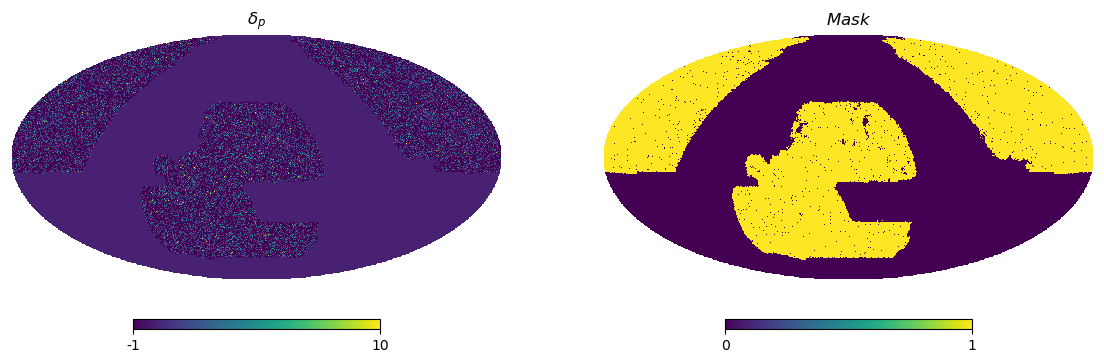

In [20]:
nside = 1024
lmax = 3*nside - 1
ipix_ran = hp.ang2pix(nside, randoms['RA'], randoms['DEC'], lonlat=True)
nbar_all = []
cl_pix_all = []
nl_all = []
for jb, bin_index in enumerate(range(1, nbins_gals+1)):
    pos_data = np.array([cat['RA'], cat['DEC']])
    w_data = cat['weight']/np.mean(cat['weight'])
    ind_sel_zbin = cat['pz_bin'] == bin_index
    pos_data = pos_data[:, ind_sel_zbin]

    ipix = hp.ang2pix(nside, pos_data[0, :], pos_data[1, :], lonlat=True)
    npix = hp.nside2npix(nside)

    nmap = np.bincount(ipix, minlength=npix, weights=w_data[ind_sel_zbin])
    mask = np.bincount(ipix_ran, minlength=npix)
    mask[mask>0] = 1
    nbar = np.sum(nmap)/np.sum(mask)
    nbar_all.append(nbar)

    nbar_map = nbar * mask
    good = mask > 0
    delta = np.zeros(npix)
    delta[good] = nmap[good]/nbar_map[good]-1

    # To compute Cls using pixel based approach and get the shot-noise estimate:
    b = nmt.NmtBin.from_lmax_linear(lmax, nlb=100)
    f_pix = nmt.NmtField(mask, [delta], n_iter=0)
    wpix = nmt.NmtWorkspace.from_fields(f_pix, f_pix, b)
    pcl = nmt.compute_coupled_cell(f_pix, f_pix)
    cl = wpix.decouple_cell(pcl)
    pnl = 4*np.pi*np.mean(mask)/(npix*nbar)
    nl = wpix.decouple_cell(pnl*np.ones_like(pcl))
    cl_pix = cl-nl
    cl_pix_all.append(cl_pix)
    nl_all.append(nl)

# Visualize delta map for the last bin:


fig, axes = plt.subplots(1, 2, figsize=(14, 10))
plt.axes(axes[0])
hp.mollview(delta, title=r'$\delta_p$', hold=True, max=10)
plt.axes(axes[1])
hp.mollview(mask, title='$Mask$', hold=True)





In [21]:
cl_cat_all = []
f_cat_all = []
for jb, bin_index in enumerate(range(1, nbins_gals+1)):
    pos_data = np.array([cat['RA'], cat['DEC']])
    w_data = cat['weight']/np.mean(cat['weight'])
    ind_sel_zbin = cat['pz_bin'] == bin_index
    pos_data = pos_data[:, ind_sel_zbin]
    w_data = w_data[ind_sel_zbin]
    print(pos_data.shape, w_data.shape)

    pos_ran = np.array([randoms['RA'], randoms['DEC']])
    w_ran = np.ones(len(randoms))

    b = nmt.NmtBin.from_lmax_linear(lmax, nlb=100)
    leff = b.get_effective_ells()
    f_cat = nmt.NmtFieldCatalogClustering(pos_data, w_data, pos_ran, w_ran, lmax=lmax, lonlat=True)
    f_cat_all.append(f_cat)

    w_cat = nmt.NmtWorkspace.from_fields(f_cat, f_cat, b)
    pcl = nmt.compute_coupled_cell(f_cat, f_cat)
    cl_cat = w_cat.decouple_cell(pcl)
    cl_cat_all.append(cl_cat)





(2, 1363585) (1363585,)
(2, 2465215) (2465215,)
(2, 2703778) (2703778,)
(2, 2469537) (2469537,)


## Compare against the published result 
### (note that binning is different, will make them same later)


In [22]:
ldir_pub_cls = '/mnt/ceph/users/spandey/xdesi/lrg_xcorr_2023/v1/clustering'
cls_pub = f'{ldir_pub_cls}/combined_cls.json'
# read json file for ell and Cls:
cls_pub_all = []
with open(cls_pub, 'r') as f:
    import json
    cls_data = json.load(f)
    ells_pub = np.array(cls_data['ell'])
    for bin_index in range(1, nbins_gals+1):
        cls_pub = np.array(cls_data['cls_fid'][f"s0{bin_index}"])
        cls_pub_all.append(cls_pub)



## Plot Cls

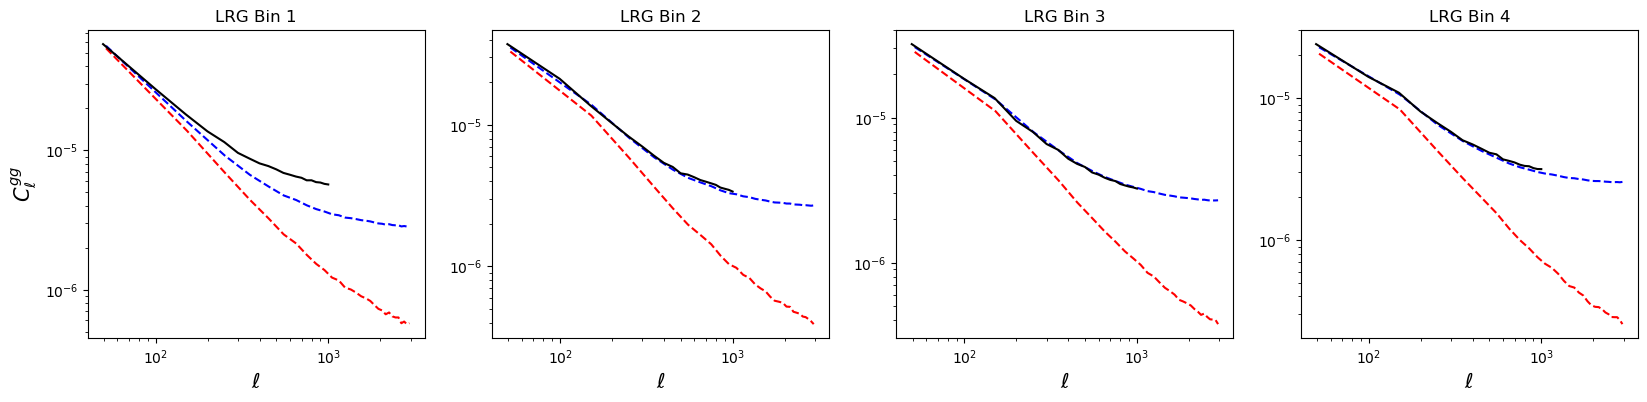

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for jb in range(nbins_gals):
    ax = axes[jb]
    cl_cat = cl_cat_all[jb]
    cls_pub = cls_pub_all[jb]
    ax.plot(leff, cl_cat[0], 'r--', label='Catalog-based')
    ax.plot(leff, cl_cat[0] + nl_all[jb][0], 'b--', label='Catalog-based' +  '\n' + 'random shot noise added')
    ax.plot(ells_pub, cls_pub, 'k-', label='Published')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\ell$', fontsize=15)
    ax.set_title(f'LRG Bin {jb+1}')
    if jb==0:
        ax.set_ylabel(r'$C^{gg}_\ell$', fontsize=15)



## CMB Lensing map:


In [24]:
ldir_lensing = '/mnt/ceph/users/spandey/xdesi/act/lensing/baseline'
alms = f'{ldir_lensing}/kappa_alm_data_act_dr6_lensing_v1_baseline.fits'



In [25]:
kappa = hp.read_alm(f'{ldir_lensing}/kappa_alm_data_act_dr6_lensing_v1_baseline.fits')
kappa = np.nan_to_num(kappa)
map_kappa = hp.alm2map(kappa.astype(np.complex128), nside)
from pixell import enmap, enplot, reproject, curvedsky as cs,utils
mask = hp.read_map(f'{ldir_lensing}/mask_act_dr6_lensing_v1_healpix_nside_4096_baseline.fits')
mask = hp.ud_grade(mask, nside_out=nside)

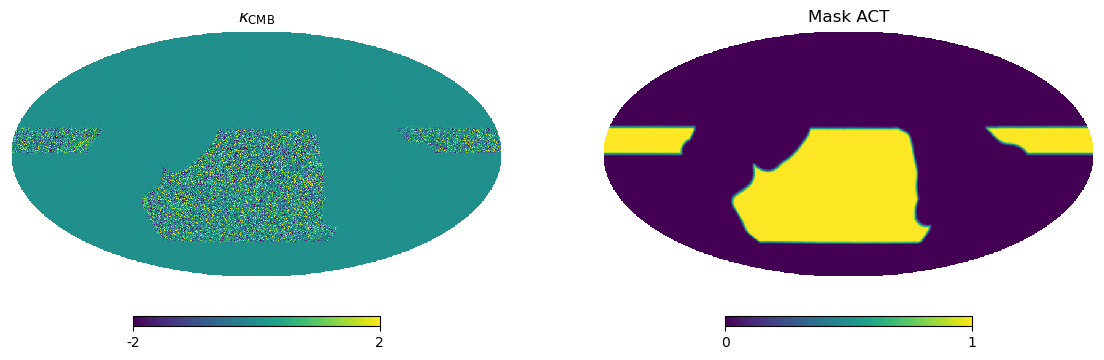

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
plt.axes(axes[0])
hp.mollview(map_kappa, title=r'$\kappa_{\rm CMB}$', hold=True, max=2, min=-2)
plt.axes(axes[1])
hp.mollview(mask, title='Mask ACT', hold=True)



In [27]:
f_0 = nmt.NmtField(mask**2, [map_kappa])
cl_cat_kappa_all = []
for jb in range(nbins_gals):
    f_cat = f_cat_all[jb]
    w = nmt.NmtWorkspace.from_fields(f_cat, f_0, b)
    cl = w.decouple_cell(nmt.compute_coupled_cell(f_cat, f_0))
    cl_cat_kappa_all.append(cl)
    
leff = b.get_effective_ells()

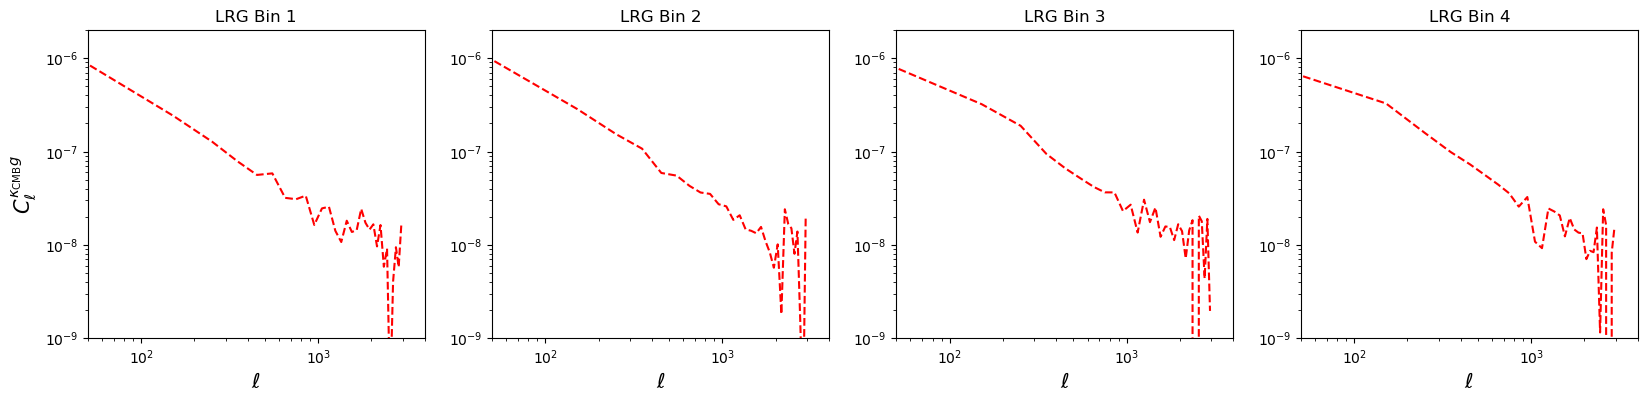

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for jb in range(nbins_gals):
    ax = axes[jb]
    cl_cat_kappa = cl_cat_kappa_all[jb]
    ax.plot(leff, cl_cat_kappa[0], 'r--', label='Catalog-based')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\ell$', fontsize=15)
    ax.set_title(f'LRG Bin {jb+1}')
    if jb==0:
        ax.set_ylabel(r'$C^{\kappa_{\rm CMB} g}_\ell$', fontsize=15)
    ax.set_xlim([50, 4000])
    ax.set_ylim(1e-9, 2e-6)



## DES Y3 galaxy weak lensing map

In [36]:
ldir_des = '/mnt/ceph/users/spandey/xdesi/des/kappa_WL'
# kappa_des = hp.ud_grade(hp.read_map(f'{ldir_des}/nullB_tomo4.fits'), nside)
kappa_des = hp.ud_grade(hp.read_map(f'{ldir_des}/KS_tomo4.fits'), nside)
mask_des = hp.ud_grade(hp.read_map(f'{ldir_des}/glimpse_mask.fits'), nside)




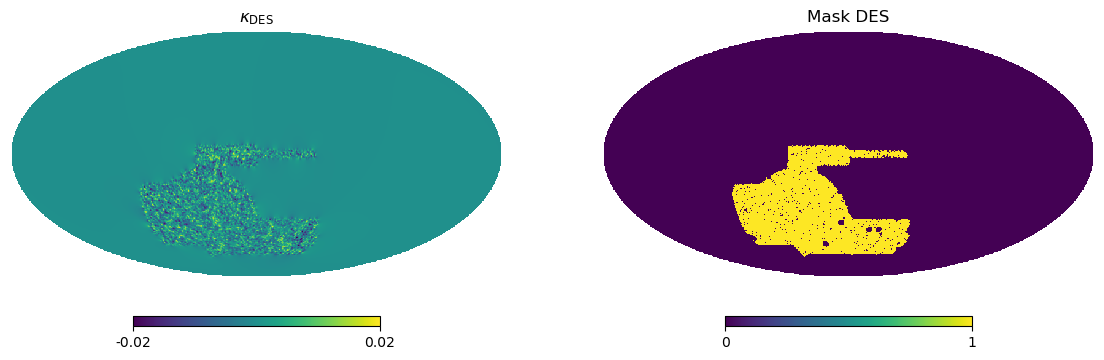

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
plt.axes(axes[0])
hp.mollview(kappa_des, title=r'$\kappa_{\rm DES}$', hold=True, max=2e-2, min=-2e-2)
plt.axes(axes[1])
hp.mollview(mask_des, title='Mask DES', hold=True)



In [38]:
f_0 = nmt.NmtField(mask_des, [kappa_des])
cl_cat_kappa_des_all = []
for jb in range(nbins_gals):
    f_cat = f_cat_all[jb]
    w = nmt.NmtWorkspace.from_fields(f_cat, f_0, b)
    cl = w.decouple_cell(nmt.compute_coupled_cell(f_cat, f_0))
    cl_cat_kappa_des_all.append(cl)
    
leff = b.get_effective_ells()




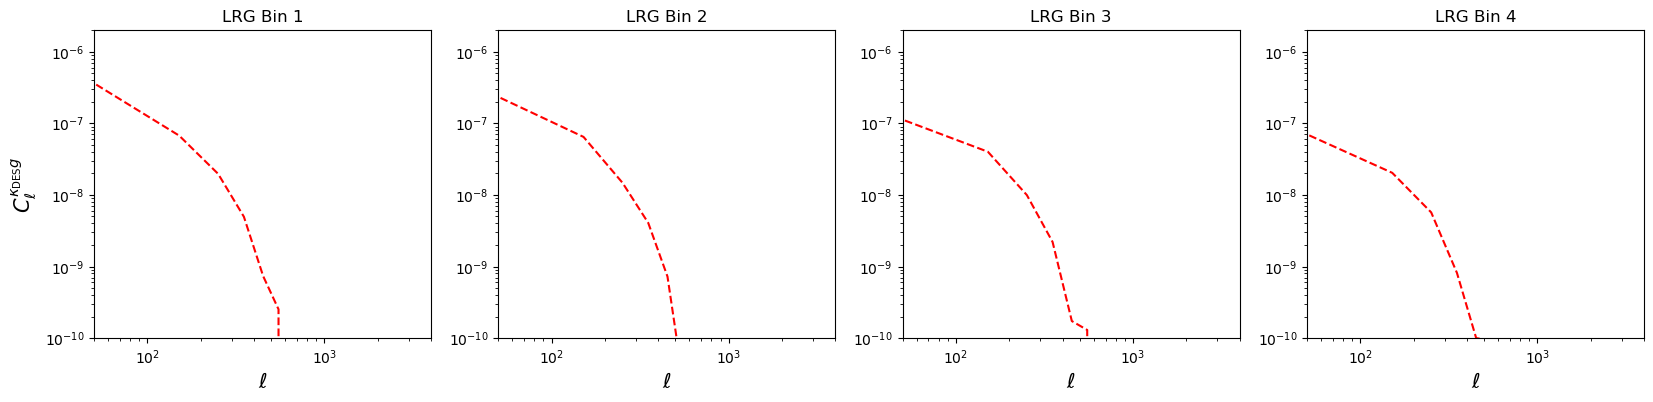

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for jb in range(nbins_gals):
    ax = axes[jb]
    cl_cat_kappa = cl_cat_kappa_des_all[jb]
    ax.plot(leff, cl_cat_kappa[0], 'r--', label='Catalog-based')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\ell$', fontsize=15)
    ax.set_title(f'LRG Bin {jb+1}')
    if jb==0:
        ax.set_ylabel(r'$C^{\kappa_{\rm DES} g}_\ell$', fontsize=15)
    ax.set_xlim([50, 4000])
    ax.set_ylim(1e-10, 2e-6)



## tSZ map

In [ ]:
from pixell import enmap, enplot, utils, curvedsky, reproject

def eshow(x,**kwargs):
    ''' Define a function to help us plot the maps neatly '''
    plots = enplot.get_plots(x, **kwargs)
    enplot.show(plots, method = "ipython")

    

In [ ]:
ldir_y = '/mnt/ceph/users/spandey/xdesi/act/tsz/cib_cibdBeta'
ymask = enmap.read_map(f"{ldir_y}/wide_mask_GAL080_apod_1.50_deg_wExtended.fits")
ymask = enmap.downgrade(ymask,2)

NSIDE = nside
ELLMAX = 2*NSIDE
ymask_hp = reproject.map2healpix(ymask, nside=NSIDE, lmax=ELLMAX)

ymap = enmap.read_map(f"{ldir_y}/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.7_10.7.fits") #downgraded map
ymap = enmap.downgrade(ymap,2)

ymap_hp = reproject.map2healpix(ymap, nside=NSIDE, lmax=ELLMAX)




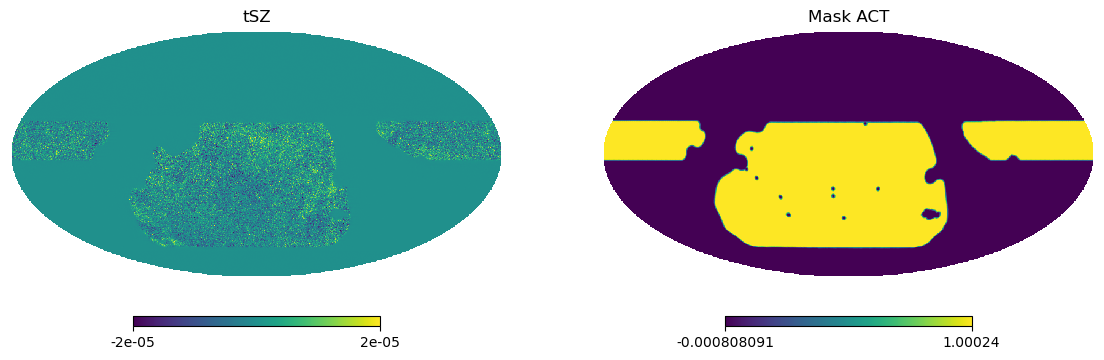

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
plt.axes(axes[0])
hp.mollview(ymap_hp, title='tSZ', hold=True, max=2e-5, min=-2e-5)
plt.axes(axes[1])
hp.mollview(ymask_hp, title='Mask ACT', hold=True)



In [ ]:
f_y = nmt.NmtField(ymask_hp, [ymap_hp]) 
cl_cat_y_all = []
for jb in range(nbins_gals):
    f_cat = f_cat_all[jb]
    w = nmt.NmtWorkspace.from_fields(f_cat, f_y, b)
    cl_gy = w.decouple_cell(nmt.compute_coupled_cell(f_cat, f_y))
    cl_cat_y_all.append(cl_gy)


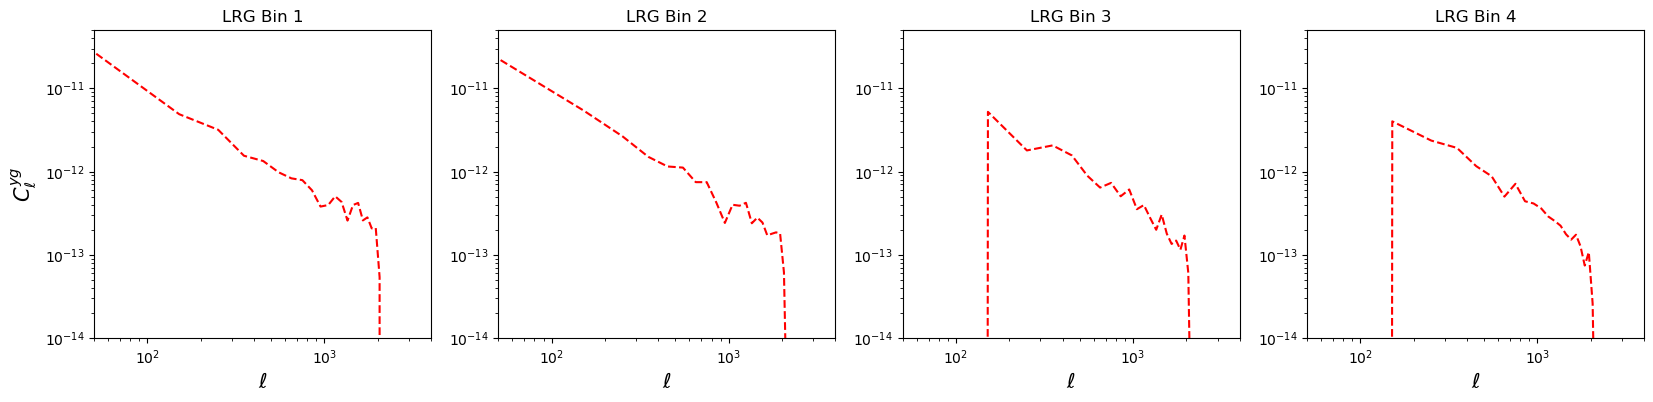

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for jb in range(nbins_gals):
    ax = axes[jb]
    cl_cat_y = cl_cat_y_all[jb]
    ax.plot(leff, cl_cat_y[0], 'r--', label='Catalog-based')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\ell$', fontsize=15)
    ax.set_title(f'LRG Bin {jb+1}')
    if jb==0:
        ax.set_ylabel(r'$C^{y g}_\ell$', fontsize=15)
    ax.set_xlim([50, 4000])
    ax.set_ylim(1e-14, 5e-11)

